In [12]:
import pandas as pd
import numpy as np
import pystormtracker as pst
import xarray as xr
import json 

In [57]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin((p2 - p1) / 2) ** 2
         + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

def storm_disk(ds, time, lat, lon, radius_km=1000):
    deg = radius_km / 111.0 * 1.5                     
    lon_pad = deg / max(np.cos(np.radians(lat)), 0.2) # longitude degrees shrink with latitude
    sub = ds.sel(
        time=time,
        lat=slice(lat - deg, lat + deg),         
        lon=slice(lon - lon_pad, lon + lon_pad),
    )
    LON, LAT = xr.broadcast(sub.lon, sub.lat)
    dist = haversine_km(lat, lon, LAT, LON)
    return sub.where(dist <= radius_km)

In [76]:
with open("/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/PyStormTracker/json/tracks_feb_04.trackjson") as f:
    d = json.load(f)

data, v = d["data"], d["data"]["variables"]

v.keys()

dict_keys(['object_gridcell_area_km2', 'object_moment_fitted_area_km2', 'object_moment_major_axis_km', 'object_moment_minor_axis_km', 'object_moment_orientation_degrees', 'raw_value', 'vo'])

In [79]:
df = pd.DataFrame({
    "time":     pd.to_datetime(data["times"], unit="ms"),
    "lat":      data["lats"],
    "lon":      data["lons"],
    "vo":       v["vo"],
    "major_km": v["object_moment_major_axis_km"],
    "minor_km": v["object_moment_minor_axis_km"],
})

In [61]:
df["track_id"] = np.repeat(d["index"]["ids"], np.diff(d["index"]["offsets"]))

In [62]:
df['track_id']

0       23
1       23
2       23
3       23
4       23
      ... 
129    673
130    673
131    673
132    673
133    673
Name: track_id, Length: 134, dtype: int64

In [94]:
ds = xr.open_dataset("/Users/annasophiamaxen/Desktop/PYTHON/master_thesis/PyStormTracker/Data/vars_feb_04_stepType-instant.nc").rename({"valid_time": "time", "latitude": "lat", "longitude": "lon"})
if float(ds.lon.max()) > 180:
    ds = ds.assign_coords(lon=((ds.lon + 180) % 360) - 180).sortby("lon")

ds = ds.sortby("lat")  

df["on_edge"] = (
    (df.lat >= 79.99) | (df.lat <= 30.01) |
    (df.lon >= 39.99) | (df.lon <= -79.99)
)

df["radius_km"] = (df.major_km / 2).clip(lower=300, upper=1500)

lat_lo, lat_hi = float(ds.lat.min()), float(ds.lat.max())
lon_lo, lon_hi = float(ds.lon.min()), float(ds.lon.max())

inside = df.lat.between(lat_lo, lat_hi) & df.lon.between(lon_lo, lon_hi)
work = df[inside & ~df.on_edge]

In [71]:
out, skipped = [], []

for r in work.itertuples():                          
    disk = storm_disk(ds, r.time, r.lat, r.lon, r.radius_km)
    if disk is None or disk["msl"].count() == 0:
        skipped.append((r.track_id, r.time, r.lat, r.lon))
        continue
    ws = np.hypot(disk["u10"], disk["v10"])
    out.append({
        "track_id": r.track_id, "time": r.time, "lat": r.lat, "lon": r.lon,
        "min_msl_hPa": float(disk["msl"].min()) / 100,
        "max_wind_ms": float(ws.max()),
        "mean_t2m_K":  float(disk["t2m"].mean()),
    })
summary = pd.DataFrame(out)
print(len(out), "processed,", len(skipped), "skipped")

72 processed, 0 skipped


In [97]:
separate_tracks = summary.groupby("track_id")

separate_tracks['min_msl_hPa'].mean()

track_id
23      980.232188
47     1008.235000
65     1012.218864
75     1003.816591
113     996.597083
347     985.458789
641    1002.775703
667     995.342448
Name: min_msl_hPa, dtype: float64

(array([1., 0., 0., 1., 2., 0., 1., 1., 0., 2.]),
 array([ 8.48191738, 10.36212778, 12.24233818, 14.12254858, 16.00275898,
        17.88296938, 19.76317978, 21.64339018, 23.52360058, 25.40381098,
        27.28402138]),
 <BarContainer object of 10 artists>)

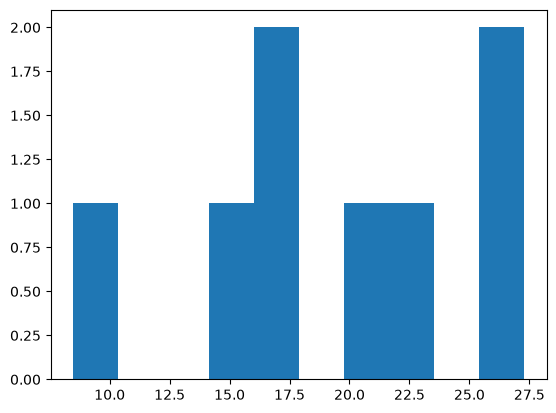

In [92]:
import matplotlib.pyplot as plt

plt.hist(separate_tracks['max_wind_ms'].max())